In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import seaborn as sns

sns.set_style('darkgrid')
np.random.seed(1)

In [3]:
# generowanie danych, wyswietlenie shape
nb_of_samples = 30        # wg wariantu 10
sequence_len = 20        # wg wariantu 10

X = np.zeros((nb_of_samples, sequence_len))

for i in range(nb_of_samples):
    # wg wariantu 10 - wartości z zakresu 0, 0.2,..., 1
    X[i, :] = np.round(np.random.rand(sequence_len) * 5) / 5

t = np.sum(X, axis=1)

print("X.shape =", X.shape)

X.shape = (30, 20)


In [4]:
# forward - krok w przod
def update_state(xk, sk, wx, wRec):
    return xk * wx + sk * wRec

def forward_states(X, wx, wRec):
    S = np.zeros((X.shape[0], X.shape[1] + 1))
    for k in range(X.shape[1]):
        S[:, k+1] = update_state(X[:, k], S[:, k], wx, wRec)
    return S

def loss(y, t):
    return np.mean((y - t)**2)

In [9]:
# BPTT - krok wstecz
def output_gradient(y, t):
    return 2 * (y - t) / y.shape[0]

def backward_gradient(X, S, grad_out, wRec):
    grad_over_time = np.zeros((X.shape[0], X.shape[1] + 1))
    grad_over_time[:, -1] = grad_out

    wx_grad = 0
    wRec_grad = 0

    for k in range(X.shape[1], 0, -1):
        wx_grad += np.sum(grad_over_time[:, k] * X[:, k-1])
        wRec_grad += np.sum(grad_over_time[:, k] * S[:, k-1])
        grad_over_time[:, k-1] = grad_over_time[:, k] * wRec

    return (wx_grad, wRec_grad), grad_over_time

In [10]:
# test forward, wyswietlenie shape
S = forward_states(X, 1.0, 1.0)
print("S.shape =", S.shape)

grad_out = output_gradient(S[:, -1], t)
_, grad_over_time = backward_gradient(X, S, grad_out, 1.0)

print("grad_over_time.shape =", grad_over_time.shape)

S.shape = (30, 21)
grad_over_time.shape = (30, 21)


In [11]:
# sprawdzenie gradientu / gradient check
params = [1.2, 1.2]
eps = 1e-7

S = forward_states(X, params[0], params[1])
grad_out = output_gradient(S[:, -1], t)
backprop_grads, _ = backward_gradient(X, S, grad_out, params[1])

for i in range(2):
    params[i] += eps
    plus_loss = loss(forward_states(X, params[0], params[1])[:, -1], t)

    params[i] -= 2 * eps
    minus_loss = loss(forward_states(X, params[0], params[1])[:, -1], t)

    params[i] += eps

    grad_num = (plus_loss - minus_loss) / (2 * eps)

    if not np.isclose(grad_num, backprop_grads[i]):
        raise ValueError("Gradient mismatch!")

print("Gradient OK")

Gradient OK


In [13]:
# punkty do zaznaczenia - tak jak w przykładzie
points = [
    (2, 1, 'r'),
    (1, 2, 'b'),
    (1, -2, 'm'),
    (1, 0, 'c'),
    (1, 0.5, 'g'),
    (1, -0.5, 'y')
]

# zdefiniowanie funkcji pomocniczych

def get_loss_surface(w1_low, w1_high, w2_low, w2_high, nb_of_ws, loss_func):
    w1 = np.linspace(w1_low, w1_high, nb_of_ws)
    w2 = np.linspace(w2_low, w2_high, nb_of_ws)
    ws1, ws2 = np.meshgrid(w1, w2)

    loss_ws = np.zeros((nb_of_ws, nb_of_ws))

    for i in range(nb_of_ws):
        for j in range(nb_of_ws):
            loss_ws[i, j] = loss_func(ws1[i, j], ws2[i, j])

    return ws1, ws2, loss_ws


def plot_surface(ax, ws1, ws2, loss_ws):
    surf = ax.contourf(
        ws1, ws2, loss_ws,
        levels=np.logspace(-2, 6, 30),
        cmap=cm.viridis,
        norm=LogNorm()
    )
    ax.set_xlabel('$w_x$')
    ax.set_ylabel('$w_{rec}$')
    return surf


def plot_points(ax, points):
    for wx, wRec, c in points:
        ax.plot(wx, wRec, c + 'o')


def get_loss_surface_figure(loss_func, points):
    fig = plt.figure(figsize=(10, 4))

    # szeroki widok
    ax1 = fig.add_subplot(1, 2, 1)
    ws1, ws2, loss_ws = get_loss_surface(-3, 3, -3, 3, 50, loss_func)
    surf = plot_surface(ax1, ws1, ws2, loss_ws + 1)
    plot_points(ax1, points)

    # zoom
    ax2 = fig.add_subplot(1, 2, 2)
    ws1, ws2, loss_ws = get_loss_surface(0, 2, 0, 2, 50, loss_func)
    plot_surface(ax2, ws1, ws2, loss_ws + 1)
    plot_points(ax2, points)

    fig.colorbar(surf)
    plt.suptitle("Loss surface")
    return fig


def get_grad_over_time(wx, wRec):
    S = forward_states(X, wx, wRec)
    grad_out = output_gradient(S[:, -1], t)
    _, grad_over_time = backward_gradient(X, S, grad_out, wRec)
    return grad_over_time


def plot_gradient_over_time(points):
    plt.figure(figsize=(8, 4))

    for wx, wRec, c in points:
        grad_over_time = get_grad_over_time(wx, wRec)
        summed = np.sum(grad_over_time, axis=0)

        x = np.arange(-len(summed) + 1, 1)
        plt.plot(x, summed, c + '-', label=f'({wx},{wRec})')

    plt.yscale('symlog')
    plt.xlabel("k (czas wstecz)")
    plt.ylabel("gradient")
    plt.title("Gradienty w czasie (BPTT)")
    plt.legend()
    plt.grid()
    plt.show()

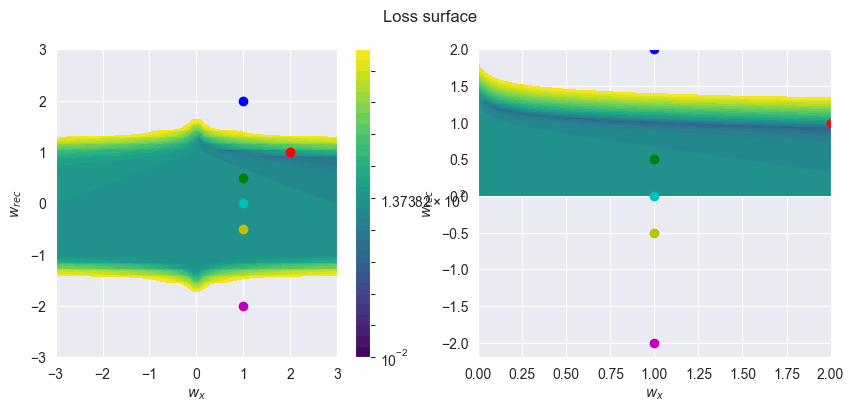

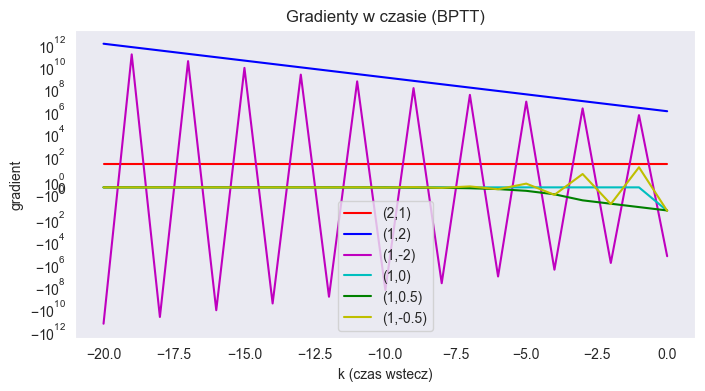

In [14]:
# wykresy
# powierzchnia błędu
fig = get_loss_surface_figure(
    lambda w1, w2: loss(forward_states(X, w1, w2)[:, -1], t),
    points
)

# gradienty w czasie
plot_gradient_over_time(points)

plt.show()

In [15]:
# zdefiniowanie funkcji RProp
def update_rprop(X, t, W, W_prev_sign, W_delta, eta_p, eta_n):
    S = forward_states(X, W[0], W[1])
    grad_out = output_gradient(S[:, -1], t)
    grads, _ = backward_gradient(X, S, grad_out, W[1])

    W_sign = np.sign(grads)

    for i in range(2):
        if W_sign[i] == W_prev_sign[i]:
            W_delta[i] *= eta_p
        else:
            W_delta[i] *= eta_n

    return W_delta, W_sign

In [16]:
# parametry z treści zadania
eta_p = 1.2
eta_n = 0.5

W = [-1.5, 2]
W_delta = [0.001, 0.001]
W_sign = [0, 0]

for i in range(300):
    W_delta, W_sign = update_rprop(X, t, W, W_sign, W_delta, eta_p, eta_n)
    for j in range(2):
        W[j] -= W_sign[j] * W_delta[j]

print("Final weights:", W)

Final weights: [np.float64(1.5602666120268927), np.float64(0.949330970874274)]


In [17]:
# ostateczny test modelu
test = np.round(np.random.rand(1, sequence_len) * 5) / 5
pred = forward_states(test, W[0], W[1])[:, -1]

print("Target:", np.sum(test))
print("Prediction:", pred[0])

Target: 11.000000000000002
Prediction: 10.745069039598889
